In [4]:
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
import seaborn as sns

# from ipywidgets import IntProgress
from IPython.display import display

# Some shared functions

In [110]:
def normalize(arr, axis=0):
    normalization_factor = arr.sum(axis, keepdims=True)
    return arr / normalization_factor

In [260]:
def define_objects(n_beings=4, n_actions=3, full_output=False):
    
    # call beings with [0,1,2,3]
    being = range(n_beings)
    # call actions with [4,5,6]
    # NOTE: calling beings and actions 
    # with different numbers is useful below
    # when using them as indices of the language array
    actions = range(n_beings, n_beings+n_actions)
    signals = range(n_beings+n_actions)

    # columns: (agent, action, patient)
    # E.g. [0,0,1] means 'first being as agent, first action, second being as patient'
    scenes = np.array([
        i
        for i in it.product(being, actions, being)
        # Note: agent and patient can't be the same
        if i[0] != i[2]
    ])

    # Contains the possible interpretation 
    # functions, modelled as a function from
    # meanings to signals
    # For instance [2,1,3,...]
    # Means that meaning 0 has signal 2
    # meaning 1 has signal 1 etc.
    # Shape: (function, signal index)
    language_interpret = np.array(list(it.permutations(signals)))

    # Possible word orders 
    # 0: S, 1: V, 2: O
    word_orders = np.array(list(it.permutations(range(3))))

    # For every combination of interpretation function, 
    # word order, and scene, I need to produce which three words 
    # would be used by the language for that scene.

    # Contains for each language and scene
    # The index of the three signals that 
    # describe the scene in that language
    # dims: (interpretation function, word order, scene, 3)
    languages = []
    # for each interpretation function
    for inter in language_interpret:
        sub = []
        # for each word order
        for order in word_orders:
            subsub = []
            # for each scene
            # scene has: (agent, action, patient)
            for scene in scenes:
                # signals for [agent, action, patient]
                subsub.append(inter[scene][order])
            sub.append(subsub)
        languages.append(sub)
    languages = np.array(languages)
    
    if full_output:
        return scenes, languages, language_interpret, word_orders
    return scenes, languages

# Description of experimental setup

- 7 'referents':
    - 4 beings
    - 3 transitive actions
- 7 words
    - One for each referent
- Hypotheses 
    - Hypothesis space is the space of languages
    - Each language consists of a lexical interpretation function and a grammar (word order)
    - Interpretation function attributes one meaning to each word. There's 7! many of them (5040)
    - Grammar is just one of 6 possible word orders
    - Total of 30240 possible languages
- Priors
    - Possibly prior preference for some word orders
    - No prior knowledge about which words refer to which referents
    - I think it's reasonable to assume that the participant thinks that the interpretation function is a bijection (i.e. no homonymy or synonymy)
- Data:
    - Each observation consists of:
    - 4 scenes (each consisting of one agent, one patient, and one transitive action)
    - 1 utterance
    - 1 selected scene
    - Whether the utterance applies to the scene
- Model
    - Purely inferential model isn't enough, because the agent is also *acting* to get as much information as possible.
    - Some kind of utility optimization
    - The model has two components:
        - Updating the knowledge about the language after each observation:
            - If the utterance and selected scene are compatible, then some interpretation functions can be eliminated
            - If not, the fact that the utterance had to apply to one of the remaining three scenes still contains information.
        - Picking the next scene from the list of 4, given an utterance and current distribution over languages.
            - Two possible aims: choose to reduce uncertainty about language, or try to get it right.
- Modeling less-than-perfect rationality
    - Qualitatively, the main problem is that there's too much information to remember
    - In other words, it is likely participant only use part of the information
    - At any given point, they might be testing specific hypotheses about the true language
    - But modeling this kind of discrete reasoning is practically impossible
    - Unfortunately, because each trial is correlated with previous ones, not modelling the early ones properly can ruin inference about the later ones.
        - Can this be helped without explicitly modelling inference process?

# Basic Bayesian model for joint inference of word order and reference

## Define functions

In [232]:
def generate_trials(lang, n, scenes, n_scenes_trial):
    """
    Generate n trials from lang.
    Parameters
    ----------
    lang: array
        An array with shape (36,3)
        Containing for each scene 
        the three words used for that scene
    n: int
        The number of trials to return
    scenes: array
        The array containing the scenes
        see above for description of array
    n_scenes_trial: int
        The total number of scenes shown in each trial
        (one is true and others are confounders)
    Returns
    -------
    list of arrays
        Each array has len (trials)
        (true_scene_index, four possible choices, utterance)
    """
    index_scenes = np.array([
        np.random.choice(
            len(scenes), 
            4,
            replace=False
        )
        for _ in range(n)
    ])
    
    true_scenes_index = np.random.choice(
        np.arange(n_scenes_trial), 
        size=len(index_scenes)
    )
    true_scenes = index_scenes[
        np.arange(len(index_scenes)),
        true_scenes_index
    ]
    utterances = lang[true_scenes]
    return true_scenes, index_scenes, utterances


def define_priors():
    word_order_prior = normalize([1]*len(word_orders)) # normalize([1,1,1,1,1,5])
    interpret_prior = normalize([1]*len(language_interpret))
    return word_order_prior, interpret_prior


def choose_scene(utterance_by_language, indices_scenes, current_state):
    """
    Choose a scene based on current posterior
    say by sampling with model averaging
    Get for each scene P(scene | utterance, language)P(language)
    And then sum across languages
    """
    # I want the joint probability of each scene & language
    # given the utterance
    # restrict to just available scenes
    p_lang_scene_given_utt = utterance_by_language[:,:,indices_scenes] 
    # multiply with prior over languages
    p_lang_scene_given_utt = p_lang_scene_given_utt * current_state[:,:,None]
    # sum over languages to get probability of 
    # each of the four scenes given the utterance
    p_scene = normalize(p_lang_scene_given_utt, axis=(0,1,2)).sum((0,1))
    chosen_scene = np.random.choice(indices_scenes, p=p_scene)
    return chosen_scene


def update_knowledge(chosen_scene, true_scene, languages, utterance, 
                     indices_scenes, current_state, negative_evidence):
    
    if chosen_scene == true_scene:
        # update current_state to only keep those languages
        # that are compatible with that scene and utterance
        compatible_languages = (languages == utterance).all(-1)[:,:,chosen_scene]
    elif negative_evidence:
        # otherwise it's one of the remaining three 
        # observed scenes

        # Get indices of non chosen scenes
        indices_non_chosen = indices_scenes[indices_scenes!=chosen_scene]
        # Mask for languages that use the seen utterance
        # for any of the non-chosen scenes
        compatible_languages = (languages == utterance).all(-1)[:,:,indices_non_chosen].any(-1)
    else:
        compatible_languages = np.ones_like(current_state)
    current_state = normalize(compatible_languages*current_state, axis=(0,1))
    return current_state
    

def run_experiment(trials, interpret_prior, word_order_prior, negative_evidence):
    
    # dims: (interpretation function, word order)
    # Contains the probabilities of each language
    current_state = interpret_prior[:,None] * word_order_prior

    # loop through the observations and update the posterior
    # at each timestep
    history_states = [current_state]
    history_choices = []
    for true_scene, indices_scenes, utterance in zip(*trials):

        # get indicator of utterance for each language
        # NOTE: some languages don't use a certain
        # utterance at all!
        # This gives P(scenes | language, utterance)
        # Which is always 0 or 1
        utterance_by_language = (languages == utterance).all(-1)

        chosen_scene = choose_scene(
            utterance_by_language, 
            indices_scenes, 
            current_state
        )
        history_choices.append(chosen_scene)

        current_state = update_knowledge(
            chosen_scene, 
            true_scene, 
            languages, 
            utterance, 
            indices_scenes,
            current_state,
            negative_evidence
        )
        history_states.append(current_state)
        
    return history_states, history_choices

## Show some info about objects

In [58]:
scenes.shape

(36, 3)

In [59]:
scenes[:2]

array([[0, 4, 1],
       [0, 4, 2]])

In [73]:
language_interpret.shape

(5040, 7)

In [74]:
language_interpret[:2]

array([[0, 1, 2, 3, 4, 5, 6],
       [0, 1, 2, 3, 4, 6, 5]])

In [75]:
language_interpret

array([[0, 1, 2, ..., 4, 5, 6],
       [0, 1, 2, ..., 4, 6, 5],
       [0, 1, 2, ..., 5, 4, 6],
       ...,
       [6, 5, 4, ..., 1, 2, 0],
       [6, 5, 4, ..., 2, 0, 1],
       [6, 5, 4, ..., 2, 1, 0]])

In [77]:
word_orders

array([[0, 1, 2],
       [0, 2, 1],
       [1, 0, 2],
       [1, 2, 0],
       [2, 0, 1],
       [2, 1, 0]])

In [66]:
language_interpret[:2]

array([[0, 1, 2, 3, 4, 5, 6],
       [0, 1, 2, 3, 4, 6, 5]])

In [78]:
lang = language_interpret[1000]

In [79]:
scene = scenes[0]

In [80]:
# the language has 
# signal 1 for meaning 0
# signal 3 for meaning 1
# signal 2 for meaning 2
# etc.
print(lang, scene)

[1 3 2 5 6 0 4] [0 4 1]


In [71]:
lang[scene]

array([1, 6, 3])

In [97]:
languages.shape

(5040, 6, 36, 3)

## Run simulated experiments

In [46]:
scenes, languages = define_objects()
word_order_prior, interpret_prior = define_priors()

In [53]:
index_true_language = (2,3)

trials = generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

In [61]:
history, _ = run_experiment(
    trials, interpret_prior, word_order_prior, negative_evidence=True)

In [62]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.0023148148148148147,
 0.08333333333333333,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

## Run multiple experiments

In [65]:
def run_experiments(index_true_lang, interpret_prior, word_order_prior, n, negative_evidence):
    
    scenes, languages = define_objects()
    word_order_prior, interpret_prior = define_priors()
    
    f = IntProgress(min=0, max=n)
    display(f)

    histories = []
    for i in range(n):
        index_lang = (
            index_true_lang 
            if type(index_true_lang) is tuple
            else index_true_lang[i]
        )
        trials = generate_trials(
            languages[index_lang], 
            10, 
            scenes, 
            4
        )
        histories.append(
            run_experiment(
                trials, 
                interpret_prior, 
                word_order_prior,
                negative_evidence
            )[0]
        )
        f.value += 1
    return histories

### Considering negative evidence

In [136]:
index_true_language = (2,3)

In [155]:
histories = run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

IntProgress(value=0)

In [156]:
true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

In [157]:
means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

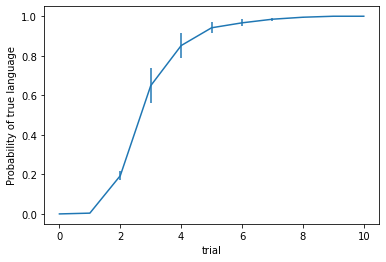

In [158]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

### Without considering negative evidence

In [136]:
index_true_language = (2,3)

In [159]:
histories = run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

IntProgress(value=0)

In [140]:
true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

In [141]:
means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

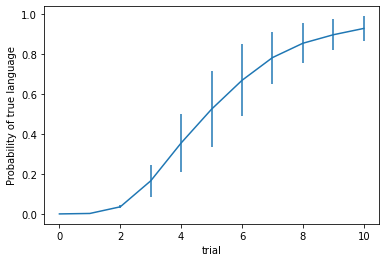

In [142]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

# Get data

In [1]:
import pandas as pd

Reproduce the data wrangling in R from the intial code

In [104]:
raw_data = pd.read_csv('../michael_data/data/results_2021-08-23T12_58_44_175Z_langlearning-v2.csv')

display(raw_data.head())

# remove xiaochen and bob results
raw_data = raw_data.iloc[38:]

data = raw_data.iloc[:,[0, 2, 6, 9, 11, 12]]

data = data.rename(columns={
    k:v
    for k,v in 
    zip(data.columns, 
        ["subject", "counter", "controller", "type", "condition", "response"])
})

data['response'] = data['response'].str.replace('%2C', ' ')

,Results index,Time,Counter,Hash,Logged in as experiment owner? (if known),Ping group,Controller name,Item number,Element number,Type,Group,Field name,Field value
0,0,2021-08-11T12:01:41Z,1,Hg6dN1u9dRkeM6rPSsln+Q,yes,default,Form,8,0,outro1,NaN,teck,1
1,0,2021-08-11T12:01:41Z,1,Hg6dN1u9dRkeM6rPSsln+Q,yes,default,Form,8,0,outro1,NaN,neep,1
2,0,2021-08-11T12:01:41Z,1,Hg6dN1u9dRkeM6rPSsln+Q,yes,default,Form,8,0,outro1,NaN,blom,1
3,0,2021-08-11T12:01:41Z,1,Hg6dN1u9dRkeM6rPSsln+Q,yes,default,Form,8,0,outro1,NaN,vode,1
4,0,2021-08-11T12:01:41Z,1,Hg6dN1u9dRkeM6rPSsln+Q,yes,default,Form,8,0,outro1,NaN,klin,1


In [107]:
data

,subject,counter,controller,type,condition,response
38,1,4,Form,outro1,klin,Triangle Alien
39,1,4,Form,outro1,praz,wave
40,1,4,Form,outro1,yabe,Pacman Alien
41,1,4,Form,outro1,subject,second
42,1,4,Form,outro1,verb,third
...,...,...,...,...,...,...
14674,386,472,Form,outro1,_REACTION_TIME_,94374
14675,386,472,Form,outro2,strategy,First trying to work out what words were in co...
14676,386,472,Form,outro2,comments,I thought for a long time into it that I was n...
14677,386,472,Form,outro2,notes,no


In [57]:
data['condition'].unique()

array(['klin', 'praz', 'yabe', 'subject', 'verb', 'object',
       '_REACTION_TIME_', 'strategy', 'comments', 'notes', 'consent',
       'age', 'language', 'prolific', 'daily_language', 'second_language',
       'later_language', 'gender', 'clickedImage', 'targetSit',
       'controlSit1', 'controlSit2', 'controlSit3', 'rt', 'nounMap',
       'verbMap', 'wordOrderBox', 'teck', 'neep', 'blom', 'vode'],
      dtype=object)

There should be this many participants: (NOTE: two of the original participants are in fact Bob and Xiaochen)

> __**TODO**__ Delete Bob and Xiaochen's results

In [59]:
64*6

384

In [110]:
chosen = data[data['condition']=='clickedImage']
chosen.loc[:,'response'] = chosen.loc[:,'response'].str.split()

In [114]:
# All participants did 200 trials
(chosen['response'].map(len) == 200).all()

True

In [116]:
# Data that was recorded for each participant
data['condition'].unique()

array(['klin', 'praz', 'yabe', 'subject', 'verb', 'object',
       '_REACTION_TIME_', 'strategy', 'comments', 'notes', 'consent',
       'age', 'language', 'prolific', 'daily_language', 'second_language',
       'later_language', 'gender', 'clickedImage', 'targetSit',
       'controlSit1', 'controlSit2', 'controlSit3', 'rt', 'nounMap',
       'verbMap', 'wordOrderBox', 'teck', 'neep', 'blom', 'vode'],
      dtype=object)

In [118]:
data[['condition', 'response']]

,condition,response
38,klin,Triangle Alien
39,praz,wave
40,yabe,Pacman Alien
41,subject,second
42,verb,third
...,...,...
14674,_REACTION_TIME_,94374
14675,strategy,First trying to work out what words were in co...
14676,comments,I thought for a long time into it that I was n...
14677,notes,no


```
for string in data[data['condition'] == 'strategy']['response']:
    print(string, '\n')
```

# Get learned language features directly from answers

A very simple model is to empirically check when people have learned the language features (word meanings + word order).

Model:
- Each participant over timesteps is encoded as a strictly increasing set of known language features.
- In particular: 
    - What each word refers to (assuming bijection between words and objects)
    - Where the verb, object, and subject is (partial knowledge is possible)
- Crucial part of the model: 
    - We know what the _true_ language is, and we know that if participants don't have the true language they'll get feedback that contradict their choices. 
    - Therefore, we can just keep track of which of the TRUE language features a participant has learned, and assume participants just sample randomly from the language until they figured out the true one.
    - In a sense, this model disregards the feedback given to participants. Just uses their choices to infer what they know at each timestep. However, it _depends_ on participants having to explore until they get to the true language, which depends on them getting feedback.
    - This model can be conceptualized as a multidimensional switchpoint model, where for each language feature, the participant goes from uniform probability (or something like that) before a certain point (the point where they figure out that language feature) to putting all probability to the true feature after a certain point (when they figure out the language).
- Crucial simplification: we don't model what _other_ language the participant is learning, just whether they have already learned the true language. The simplification is that we assume that if participants haven't yet learned the true feature, they don't believe in _another_ feature but rather just do exploration.
- Another way of looking at this is that we know what the participants will do _eventually_, namely figure out the truth, but how they do it is so complicated that we can encode it as noise. We just can't explicitly model what they mistakenly think they've learned in between.

- Having participant-wise hierarchical structure for position of switchpoint allows us to do model-comparison on how easy participants find it to infer different word orders.

Behavioural assumptions:
- At each step, the participant's knowledge state is encoded just as a Boolean vector that contains for each language feature whether the participant has learned it already
    - The boolean vector can be constructed by > comparison with the inferred switchpoints
- A knowledge state induces at each timestep a distribution over the four choices.
    - Basically, the knowledge state excludes some of the options (the ones incompatible with what the participant knows)
    - The participant chooses e.g. uniformly among the remaining ones

Free parameters:
- For each participant, the free parameters are just the positions of the switchpoint for each language feature.

Language features. Participant knows:
- Position of verb
- Position of subject
- Position of object
- Word for meaning 1
- Word for meaning 2

...

- Word for meaning 7

Note that position of verb, position of subject, and position of object are partially independent from each other. The participant might have figured out where the verb is but might be unsure which position is for subject and which for object, and viceversa. Knowing any two determines where the third is, but a participant can know just one of them. Therefore, I need to add the restriction: 
- whichever two are learned last, they are learned together. 
- This restriction means that when we're sampling the timepoints at which the positions are learned, we're effectively sampling from a 2-d surface in discrete 3-d space s.t. the two dimensions with the highest value are always equal
- There's only three ways this can happen: L(low)-H(igh)-H, HLH, HHL (position indicates verb, subject, object respectively)
- Therefore, to sample I can:
    - First, sample two numbers between 0 and max, a L(ow) and a H(igh)
    - Second, sample an order from LHH, HLH, HHL
    - Third, construct the actual numbers
- Does this way of sampling produce a reasonable prior?

The most tricky thing with this model programming-wise is how to determine efficiently whether a state and utterance are compatible given a knowledge state.

- Knowledge state is encoded by two vectors: 
    - One vector with 3 components for word order
    - One vector with 7 components for word meanings
- A sentence is encoded as an array with shape (3,3,7) and dimensions (word index, verb/subject/object, word)
- A scene is encoded as an array with shape (3,7) and dimensions (action/agent/patient, meaning)

A scene and a sentence are compatible given a language iff the language would produce the sentence for the scene. That can be calculated as:

In [124]:
import numpy as np

In [187]:
def likelihood_f(compatible_langs, utterance, indices_scenes):
    """
    probability of each scene given the utterance
    NOTE: mostly same as choose_scene above
    """
    # languages that produce the observed utterance for each scene
    utterance_by_language = tt.eq(compatible_langs, utterance).all(-1)
    # restrict to just available scenes
    p_lang_scene_given_utt = utterance_by_language[:,:,indices_scenes] 
    # sum over languages to get probability of 
    # each of the four scenes given the utterance
    # shape (4)
    p_scene = normalize(p_lang_scene_given_utt, axis=(0,1,2)).sum((0,1))
    return p_scene

In [177]:
def find_compatible_langs(interpret_knowledge, order_knowledge, true_interpret, 
                          true_order, word_orders, language_interpret, languages):
    
    # indices_compatible gives the indices
    # of the interpretation function compatible with 
    # interpret_knowledge
    # Indicator functions of languages compatible with current knowledge
    # shape (interpret funcs, word orders)
    interpret_indices_compatible = (
        ~interpret_knowledge | (language_interpret==true_interpret)
    ).all(axis=1)

    # NOTE: prima facie odd way of writing this, but note that it has to work
    # when order_knowledge is all 0!
    # Conceptually: a language is excluded only if it is *known to be wrong*
    # and included if it is compatible with everything that's known
    order_indices_compatible = (~order_knowledge | (word_orders==true_order)).all(axis=1)
    
    # get just languages that are compatible with current knowledge
    # about both interpretation and order
    compatible_langs = theano.shared(languages)[interpret_indices_compatible][:,order_indices_compatible]
    
    return compatible_langs

In [70]:
# scene
scenes, languages, language_interpret, word_orders = define_objects(4,3, full_output=True)

In [15]:
# languages encodes the signal produced by each scene in each lang
# dims: (interpretation function, word order, scene, 3)
print('languages shape: ', languages.shape)

languages shape:  (5040, 6, 36, 3)


## Calculate probability scenes for a single trial

In [16]:
# gives the signal for each meaning of the true language
true_interpret = language_interpret[0]
# gives the true word order
true_order = word_orders[0]

In [17]:
# interpret_knowledge says whether the signal
# for each meaning has been figured out yet
interpret_knowledge = np.array([1, 0, 0, 1, 0, 0, 0]).astype(bool)
# order_knowledge same but for word order
order_knowledge = np.array([1,1,1]).astype(bool)

In [18]:
compatible_langs = find_compatible_langs(
    interpret_knowledge, order_knowledge, true_interpret, 
    true_order, word_orders, language_interpret, languages
)

In [19]:
utterance = np.array([0,1,2])
indices_scenes = np.array([0,1,2,3])
p_scenes = likelihood_f(compatible_langs, utterance, indices_scenes)

In [20]:
# add noise!
p_scenes = normalize(p_scenes + np.random.exponential(scale=0.01))

In [21]:
p_scenes

array([0.32842581, 0.32842581, 0.01472256, 0.32842581])

## Calculate probabilities for one whole participant

In [243]:
import pymc3 as pm
import arviz as az
import theano 
from theano import tensor as tt

In [184]:
def calculate_p_scenes(utterance, indices_scenes, noise, **kwargs):
    # Find compatible languages for each timestep
    compatible_langs = find_compatible_langs(**kwargs)
    p_scenes = likelihood_f(
        compatible_langs, 
        utterance, 
        indices_scenes
    )
    # add noise!
    p_scenes = normalize(p_scenes + noise)
    return p_scenes

In [248]:
index_true_language = (2,3)
n_trials = 20

trials_arange = np.arange(n_trials)

# True interpretation function
true_interpret = language_interpret[index_true_language[0]]
# True word order
true_order = word_orders[index_true_language[1]]

trials = generate_trials(
    lang=languages[index_true_language], 
    n=n_trials, 
    scenes=scenes,
    n_scenes_trial=4
)

# indices_scenes_trials contains the four scenes' indices 
# seen in each trial
# (trial, 4)
# utterances_trials containg the three signals 
# observed in each trial
# (trial, 3)
_, indices_scenes_trials, utterances_trials = trials

In [249]:
history_states, history_choices = run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=False
)

# go from the actual chosen scenes to their indices
history_choices_indices = np.argwhere(
    indices_scenes_trials == np.array(history_choices)[:,None]
)[:,1]

In [255]:
with pm.Model() as model:
    
    noise = pm.Exponential(
        'noise',
        lam=6
    )
    # noise = tt.zeros(1)
    
    # interpret_discovery_timestep says for each
    # meaning at which timestep the signal for 
    # that meaning was found
    interpret_discovery_timestep = pm.DiscreteUniform(
        'index_discovered_interpret',
        lower=0, 
        upper=n_trials,
        shape=language_interpret.shape[1]
    )
    
    # interpret_discovery_timestep says for each
    # meaning at which timestep the signal for 
    # that meaning was found
    order_discovery_timestep = pm.DiscreteUniform(
        'index_discovered_order',
        lower=0, 
        upper=n_trials,
        shape=word_orders.shape[1]
    )
    
    # interpret_knowledge for each trial
    # dimensions: (trial, meaning)
    interpret_knowledge_trials = np.tile(
        trials_arange[:,None], 
        (1, language_interpret.shape[1])
    ) >= interpret_discovery_timestep
    
    # dimensions: (trial, 3)
    order_knowledge_trials = np.tile(
        trials_arange[:,None], 
        (1, word_orders.shape[1])
    ) >= order_discovery_timestep
    
    # results contains for each trial
    # the probability of the agent selecting 
    # each scene
    results,_ = theano.scan(
        fn=lambda i: calculate_p_scenes(
            theano.shared(utterances_trials)[i],
            theano.shared(indices_scenes_trials)[i],
            noise,
            # kwargs for find_compatible_langs
            interpret_knowledge = interpret_knowledge_trials[i], 
            order_knowledge = order_knowledge_trials[i], 
            true_interpret = true_interpret, 
            true_order = true_order, 
            word_orders = word_orders, 
            language_interpret = language_interpret, 
            languages = languages
        ),
        sequences=tt.arange(n_trials)
    )
    
    theano.printing.Print()(results)
    theano.printing.Print('interpret discovery')(interpret_knowledge_trials)
    theano.printing.Print('order discovery')(order_knowledge_trials)
    
    pm.Categorical('choices', p=results, observed=history_choices_indices)

 __str__ = [[0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.76296147 0.07901284 0.07901284 0.07901284]
 [0.07901284 0.76296147 0.07901284 0.07901284]
 [0.07901284 0.07901284 0.07901284 0.76296147]
 [0.76296147 0.07901284 0.07901284 0.07901284]
 [0.07901284 0.07901284 0.76296147 0.07901284]
 [0.07901284 0.07901284 0.76296147 0.07901284]
 [0.07901284 0.07901284 0.76296147 0.07901284]
 [0.07901284 0.07901284 0.07901284 0.76296147]
 [0.07901284 0.07901284 0.07901284 0.76296147]
 [0.07901284 0.07901284 0.76296147 0.07901284]]
interpret discovery __str__ = [[False False Fals

In [256]:
with model:
    samples = pm.sample(
        draws=3000, 
        return_inferencedata=True
    )

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [noise]
>CompoundStep
>>Metropolis: [index_discovered_order]
>>Metropolis: [index_discovered_interpret]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 2154 seconds.
The rhat statistic is larger than 1.2 for some parameters.
The estimated number of effective samples is smaller than 200 for some parameters.


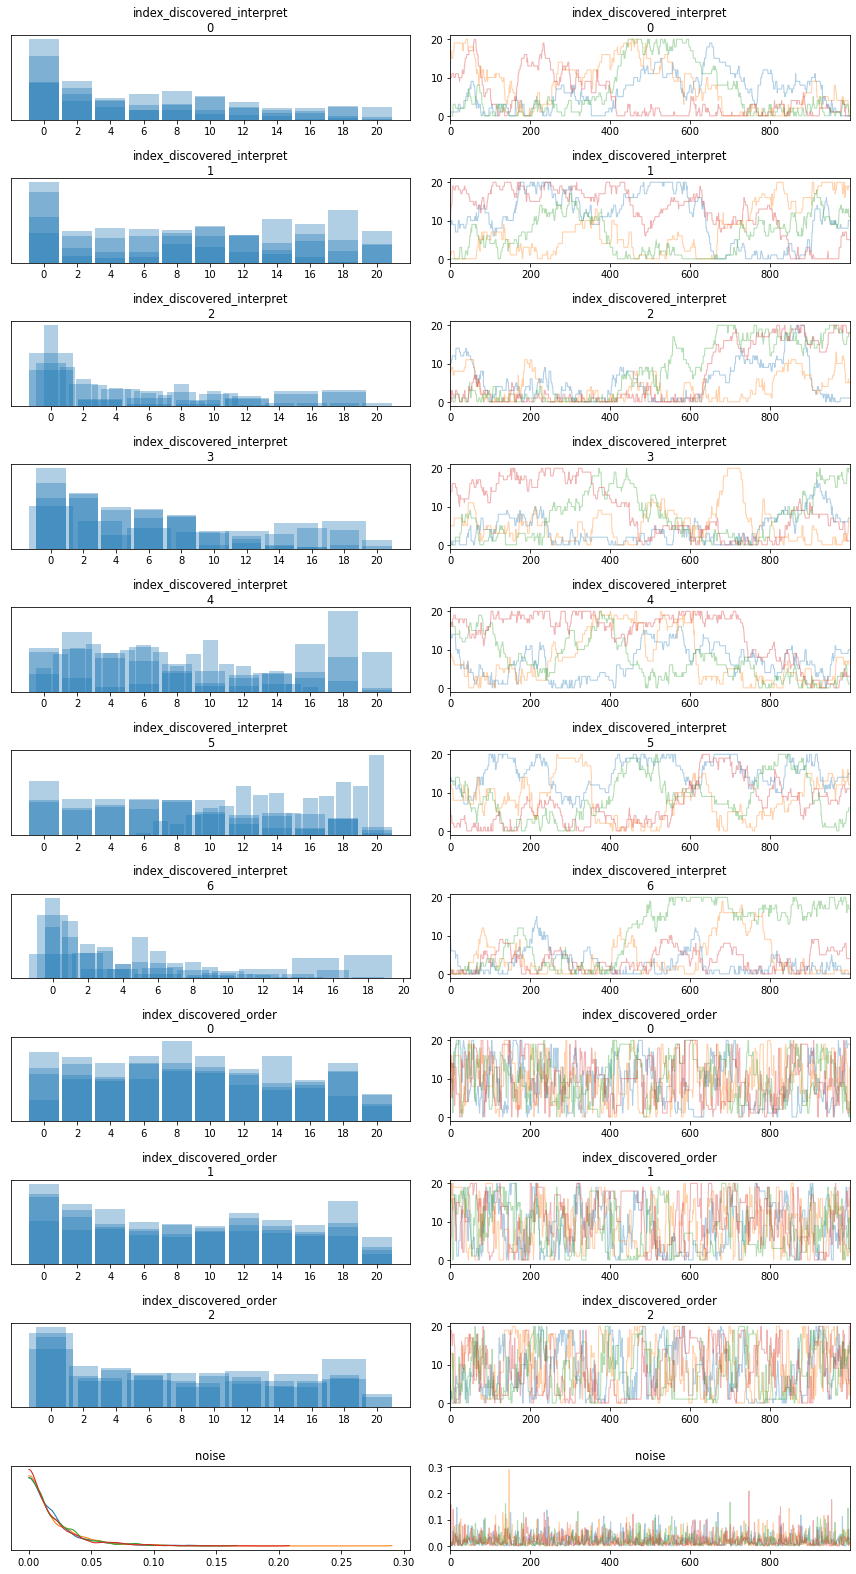

In [252]:
az.plot_trace(samples,compact=False)
plt.tight_layout()
plt.show()

# Non-Bayesian model (TODO)

I only update the rows corresponding to the words used in the signal. For instance:
- If the signal is [0, 4, 2] I update rows 0, 4, and 2 

I only update the columns corresponding to the components of the scene. For instance:
- If the scene is [2, 5, 0] I update columns 2, 5, and 0.

Each row/col combination is updated by the probability of the word (row) being the one for the object (column), across all the word orders. For instance:
- Suppose the first word in the signal is 0 and the subject in the scene is object 2
- Then I want to increment the weight for element (0,2) in interpret_weights by the probability that word 0 is the one referring to object 2. 
    - This happens iff the word order is SOV or SOV (this behaves a lot like a likelihood)
- And this is repeated for each column / row

In [479]:
def update_weights(interpretation_weights_original, word_order_weights_original, scene, signal):
    # TODO: express this as efficient linear algebra operations

    subj, act, obj = scene
    firstword, secondword, thirdword = signal
    
    interpretation_weights = interpretation_weights_original.copy()
    word_order_weights = word_order_weights_original.copy()

#     # prob that first word expresses the observed subject
#     interpretation_weights[firstword, subj] += word_order_weights[[0,1]].sum()
#     # prob that second word expresses the observed subject
#     interpretation_weights[secondword, subj] += word_order_weights[[2,4]].sum()
#     # prob that third word expresses the observed subject
#     interpretation_weights[thirdword, subj] += word_order_weights[[3,5]].sum()

#     # prob that first word expresses observed object
#     interpretation_weights[firstword, obj] += word_order_weights[[4,5]].sum()
#     # prob that second word expresses observed object
#     interpretation_weights[secondword, obj] += word_order_weights[[1,3]].sum()
#     # prob that third word expresses observed object
#     interpretation_weights[thirdword, obj] += word_order_weights[[0,2]].sum()

#     # prob that first word expresses observed action
#     interpretation_weights[firstword, act] += word_order_weights[[2,3]].sum()
#     # prob that second word expresses observed action
#     interpretation_weights[secondword, act] += word_order_weights[[0,5]].sum()
#     # prob that third word expresses observed action
#     interpretation_weights[thirdword, act] += word_order_weights[[1,4]].sum()

    # Rewrite the big chunk of code above here
    interpretation_to_add = np.zeros_like(interpretation_weights)
    # get mask for the indices that I wrote above for word_order_weights
    mask_orders = np.tile(word_orders[None], (3,1,1)) == np.array([0,1,2])[:,None,None]
    # get the values from word_order_weights
    values_to_add = word_order_weights @ mask_orders
    # add value to right locations
    interpretation_to_add[
        np.tile(signal[None], (3,1)), 
        np.tile(scene.reshape(-1,1), (1,3))
    ] = values_to_add
    
    interpretation_weights = normalize(
        interpretation_weights + interpretation_to_add,
        axis=1
    )
    
    # prob of each word order combo
    # following the word_orders array
    # and the word_order_weights array
    # Equivalent to:
    # # SVO
    # word_order_weights[0] += interpretation_weights[signal, [subj, act, obj]].prod()
    # # SOV
    # word_order_weights[1] += interpretation_weights[signal, [subj, obj, act]].prod()
    # # VSO
    # word_order_weights[2] += interpretation_weights[signal, [act, subj, obj]].prod()
    # # VOS
    # word_order_weights[3] += interpretation_weights[signal, [act, obj, subj]].prod()
    # # OSV
    # word_order_weights[4] += interpretation_weights[signal, [obj, subj, act]].prod()
    # # OV
    # word_order_weights[5] += interpretation_weights[signal, [obj, act, subj]].prod()
    
    word_order_weights = normalize(
        word_order_weights + 
        interpretation_weights[
            np.tile(signal[None], (6,1)), 
            scene[word_orders]
        ].prod(1)
    )
    
    return interpretation_weights, word_order_weights    

In [480]:
scenes, languages = define_objects()
index_true_language = (2,3)
true_scenes, index_scenes, signals = generate_trials(
    languages[index_true_language], 
    30, 
    scenes, 
    4
)

In [486]:
language_interpret[2]

array([0, 1, 2, 3, 5, 4, 6])

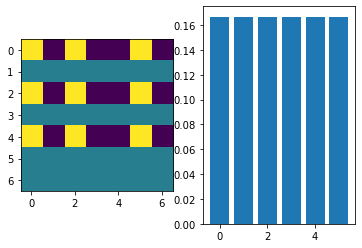

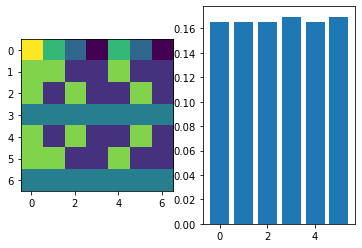

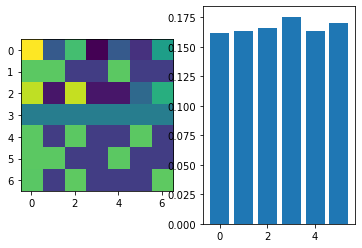

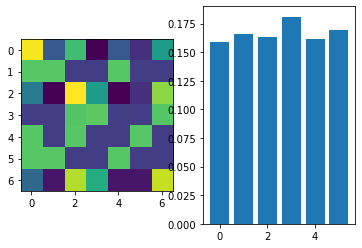

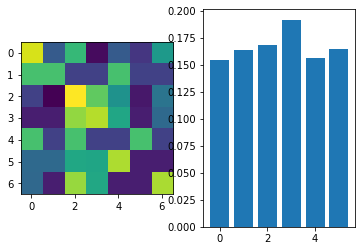

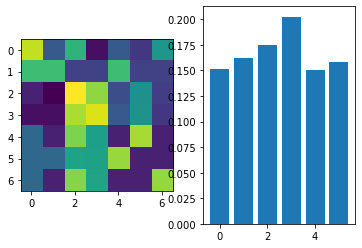

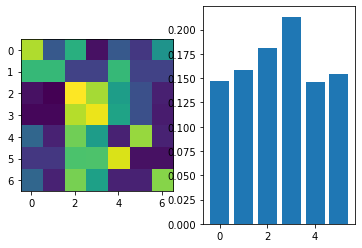

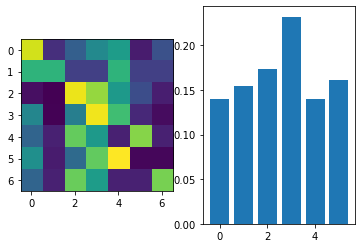

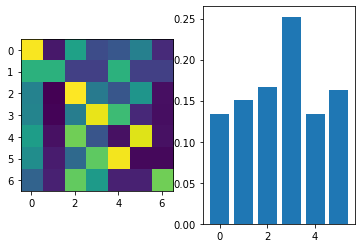

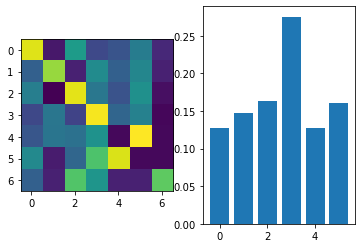

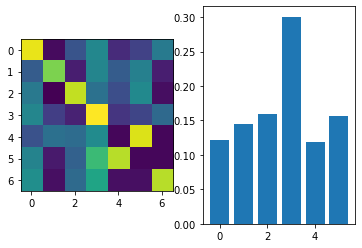

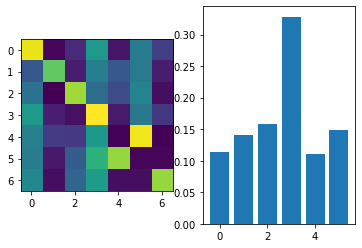

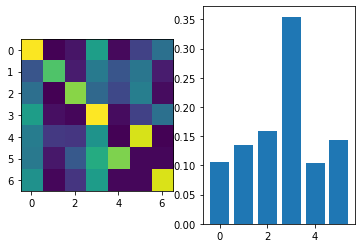

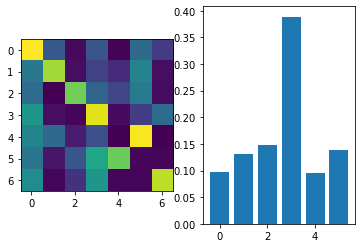

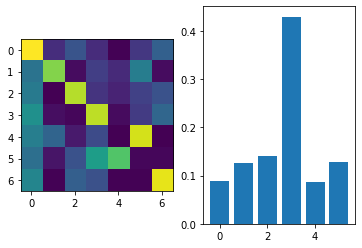

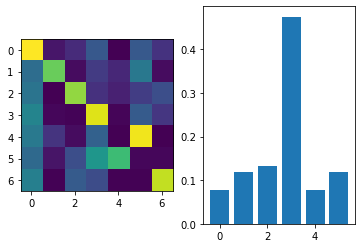

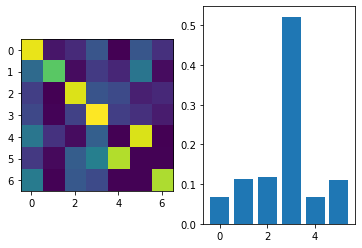

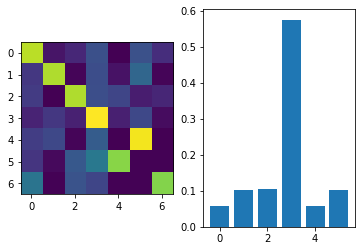

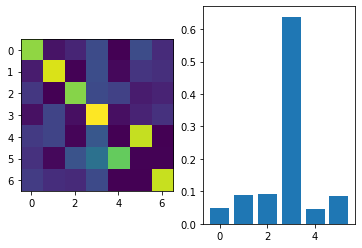

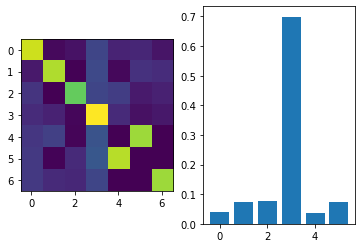

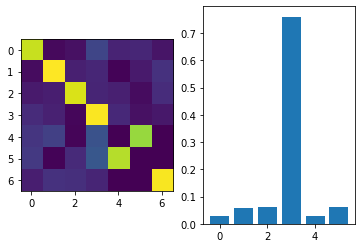

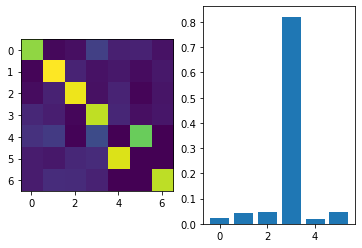

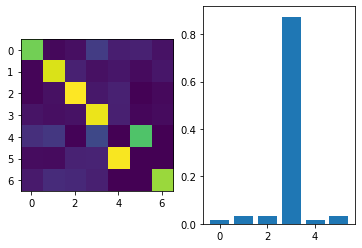

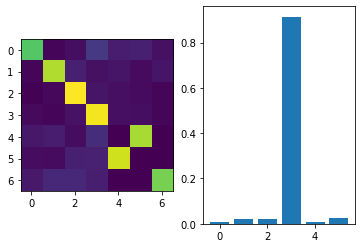

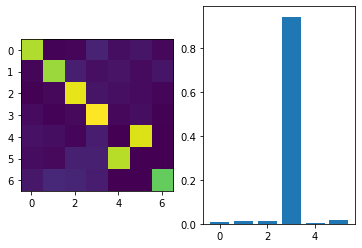

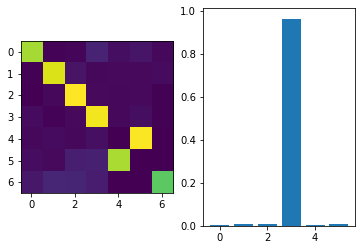

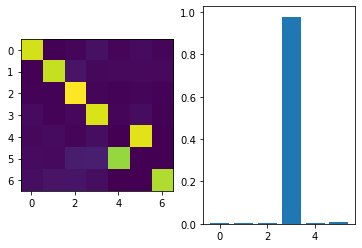

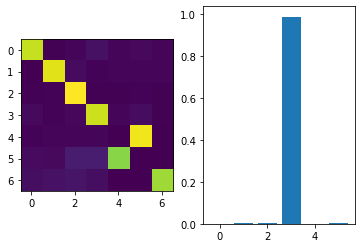

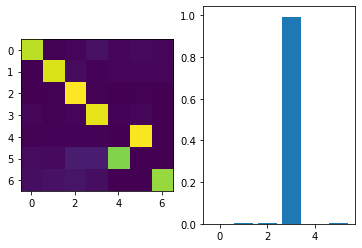

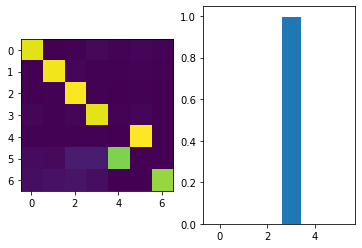

In [482]:
# dims (word, meaning)
# probability that each word has each meaning
interpretation_weights = normalize(
    np.ones((7,7)),
    axis=1
)

# dims (word order)
word_order_weights = normalize(
    np.ones(6)
)

for true_scene_index, signal in zip(true_scenes, signals):
    
    true_scene = scenes[true_scene_index]
    
    interpretation_weights, word_order_weights = update_weights(
        interpretation_weights, 
        word_order_weights, 
        true_scene, 
        signal
    )
    
    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.imshow(interpretation_weights)
    ax2.bar(np.arange(len(word_order_weights)), word_order_weights)
    plt.show()